# Batch Video Marker Tracking

Processes all jump videos (quarter, half, three-quarters, full) and produces:
- Tracking CSV and NumPy files
- Annotated videos
- Position plots and knee angle plots
- Combined comparison across all jumps

In [2]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

from src.config import BlueDetectionConfig
from src.tracker import BlueMarkerDetector, VideoMarkerTracker

%matplotlib inline

## Configuration

In [4]:
# Videos to process
VIDEO_NAMES = ["jump-quarter", "jump-half", "jump-threequarters", "jump-full"]
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load detection config
config_path = DATA_DIR / "detection_config.json"
try:
    config = BlueDetectionConfig.load(str(config_path))
    print("Loaded configuration:")
    print(config)
except FileNotFoundError:
    print(f"Config not found at {config_path}")
    print("Using default configuration. Run 01_color_tuning.ipynb first!")
    config = BlueDetectionConfig()

# Verify all videos exist
for name in VIDEO_NAMES:
    path = DATA_DIR / f"{name}.mp4"
    status = "OK" if path.exists() else "MISSING"
    print(f"  {path.name}: {status}")

Loaded configuration:
BlueDetectionConfig(
  HSV Lower: (90, 200, 50)
  HSV Upper: (130, 255, 255)
  Min Area: 500
  Max Area: 30000
  Circularity: 0.3
)
  jump-quarter.mp4: OK
  jump-half.mp4: OK
  jump-threequarters.mp4: OK
  jump-full.mp4: OK


## Helper Functions

In [6]:
def calculate_knee_angle(hip, knee, ankle):
    """Calculate knee angle in degrees (180 = straight leg)."""
    v1 = np.array([hip[0] - knee[0], hip[1] - knee[1]])
    v2 = np.array([ankle[0] - knee[0], ankle[1] - knee[1]])
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_angle = np.clip(cos_angle, -1, 1)
    return np.degrees(np.arccos(cos_angle))


def add_knee_angles(df):
    """Add knee_angle column to a tracking DataFrame."""
    angles = []
    for _, row in df.iterrows():
        if pd.notna(row['hip_x']) and pd.notna(row['knee_x']) and pd.notna(row['ankle_x']):
            angle = calculate_knee_angle(
                (row['hip_x'], row['hip_y']),
                (row['knee_x'], row['knee_y']),
                (row['ankle_x'], row['ankle_y'])
            )
            angles.append(angle)
        else:
            angles.append(np.nan)
    df['knee_angle'] = angles
    return df

## Process All Videos

In [8]:
all_dataframes = {}

for video_name in VIDEO_NAMES:
    video_path = DATA_DIR / f"{video_name}.mp4"
    if not video_path.exists():
        print(f"SKIPPING {video_name}: file not found")
        continue

    print(f"\n{'='*60}")
    print(f"Processing: {video_name}")
    print(f"{'='*60}")

    # Video info
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = total_frames / fps
    cap.release()
    print(f"  Resolution: {width}x{height}, FPS: {fps:.1f}, Frames: {total_frames}, Duration: {duration:.2f}s")

    # Track markers
    tracker = VideoMarkerTracker(config)
    with tqdm(total=total_frames, desc=video_name) as pbar:
        results = tracker.process_video(
            str(video_path),
            progress_callback=lambda f, t: pbar.update(1)
        )

    # Detection summary
    complete = sum(1 for r in results if r.is_complete)
    hip_det = sum(1 for r in results if r.hip is not None)
    knee_det = sum(1 for r in results if r.knee is not None)
    ankle_det = sum(1 for r in results if r.ankle is not None)
    total = len(results)
    print(f"  Complete (all 3): {complete}/{total} ({100*complete/total:.1f}%)")
    print(f"  Hip: {hip_det}/{total}, Knee: {knee_det}/{total}, Ankle: {ankle_det}/{total}")

    # Export CSV and NumPy
    csv_path = OUTPUT_DIR / f"{video_name}_tracking.csv"
    npy_path = OUTPUT_DIR / f"{video_name}_tracking.npy"
    tracker.export_to_csv(csv_path)
    tracking_array = tracker.export_to_numpy()
    np.save(npy_path, tracking_array)
    print(f"  CSV: {csv_path}")
    print(f"  NPY: {npy_path} (shape: {tracking_array.shape})")

    # Add knee angles and resave
    df = pd.read_csv(csv_path)
    df = add_knee_angles(df)
    df.to_csv(csv_path, index=False)
    all_dataframes[video_name] = df

    # Create annotated video
    video_output = OUTPUT_DIR / f"{video_name}_annotated.mp4"
    tracker.create_annotated_video(str(video_path), str(video_output))
    print(f"  Annotated video: {video_output}")

print(f"\n{'='*60}")
print(f"All videos processed. {len(all_dataframes)} completed.")
print(f"{'='*60}")


Processing: jump-quarter
  Resolution: 1216x2160, FPS: 30.2, Frames: 71, Duration: 2.35s


jump-quarter:   0%|          | 0/71 [00:00<?, ?it/s]

  Complete (all 3): 71/71 (100.0%)
  Hip: 71/71, Knee: 71/71, Ankle: 71/71
  CSV: ../output/jump-quarter_tracking.csv
  NPY: ../output/jump-quarter_tracking.npy (shape: (71, 9))
  Annotated video: ../output/jump-quarter_annotated.mp4

Processing: jump-half
  Resolution: 1216x2160, FPS: 30.1, Frames: 111, Duration: 3.69s


jump-half:   0%|          | 0/111 [00:00<?, ?it/s]

  Complete (all 3): 111/111 (100.0%)
  Hip: 111/111, Knee: 111/111, Ankle: 111/111
  CSV: ../output/jump-half_tracking.csv
  NPY: ../output/jump-half_tracking.npy (shape: (111, 9))
  Annotated video: ../output/jump-half_annotated.mp4

Processing: jump-threequarters
  Resolution: 1216x2160, FPS: 30.0, Frames: 130, Duration: 4.33s


jump-threequarters:   0%|          | 0/130 [00:00<?, ?it/s]

  Complete (all 3): 130/130 (100.0%)
  Hip: 130/130, Knee: 130/130, Ankle: 130/130
  CSV: ../output/jump-threequarters_tracking.csv
  NPY: ../output/jump-threequarters_tracking.npy (shape: (130, 9))
  Annotated video: ../output/jump-threequarters_annotated.mp4

Processing: jump-full
  Resolution: 1216x2160, FPS: 30.1, Frames: 105, Duration: 3.49s


jump-full:   0%|          | 0/105 [00:00<?, ?it/s]

  Complete (all 3): 105/105 (100.0%)
  Hip: 105/105, Knee: 105/105, Ankle: 105/105
  CSV: ../output/jump-full_tracking.csv
  NPY: ../output/jump-full_tracking.npy (shape: (105, 9))
  Annotated video: ../output/jump-full_annotated.mp4

All videos processed. 4 completed.


for video_name, df in all_dataframes.items():
    plt.figure(figsize=(14, 5))
    plt.plot(df['frame'], df['knee_angle'], 'b-', alpha=0.7)
    plt.xlabel('Frame')
    plt.ylabel('Knee Angle (degrees)')
    plt.title(f'{video_name} - Knee Angle Over Time')
    plt.ylim(30, 180)
    plt.axhline(y=180, color='gray', linestyle='--', alpha=0.5, label='Straight leg (180\u00b0)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{video_name}_knee_angle.png", dpi=150)
    plt.show()

    print(f"{video_name} - Knee Angle: "
          f"Min={df['knee_angle'].min():.1f}\u00b0, "
          f"Max={df['knee_angle'].max():.1f}\u00b0, "
          f"Mean={df['knee_angle'].mean():.1f}\u00b0, "
          f"Range={df['knee_angle'].max() - df['knee_angle'].min():.1f}\u00b0")
    print()

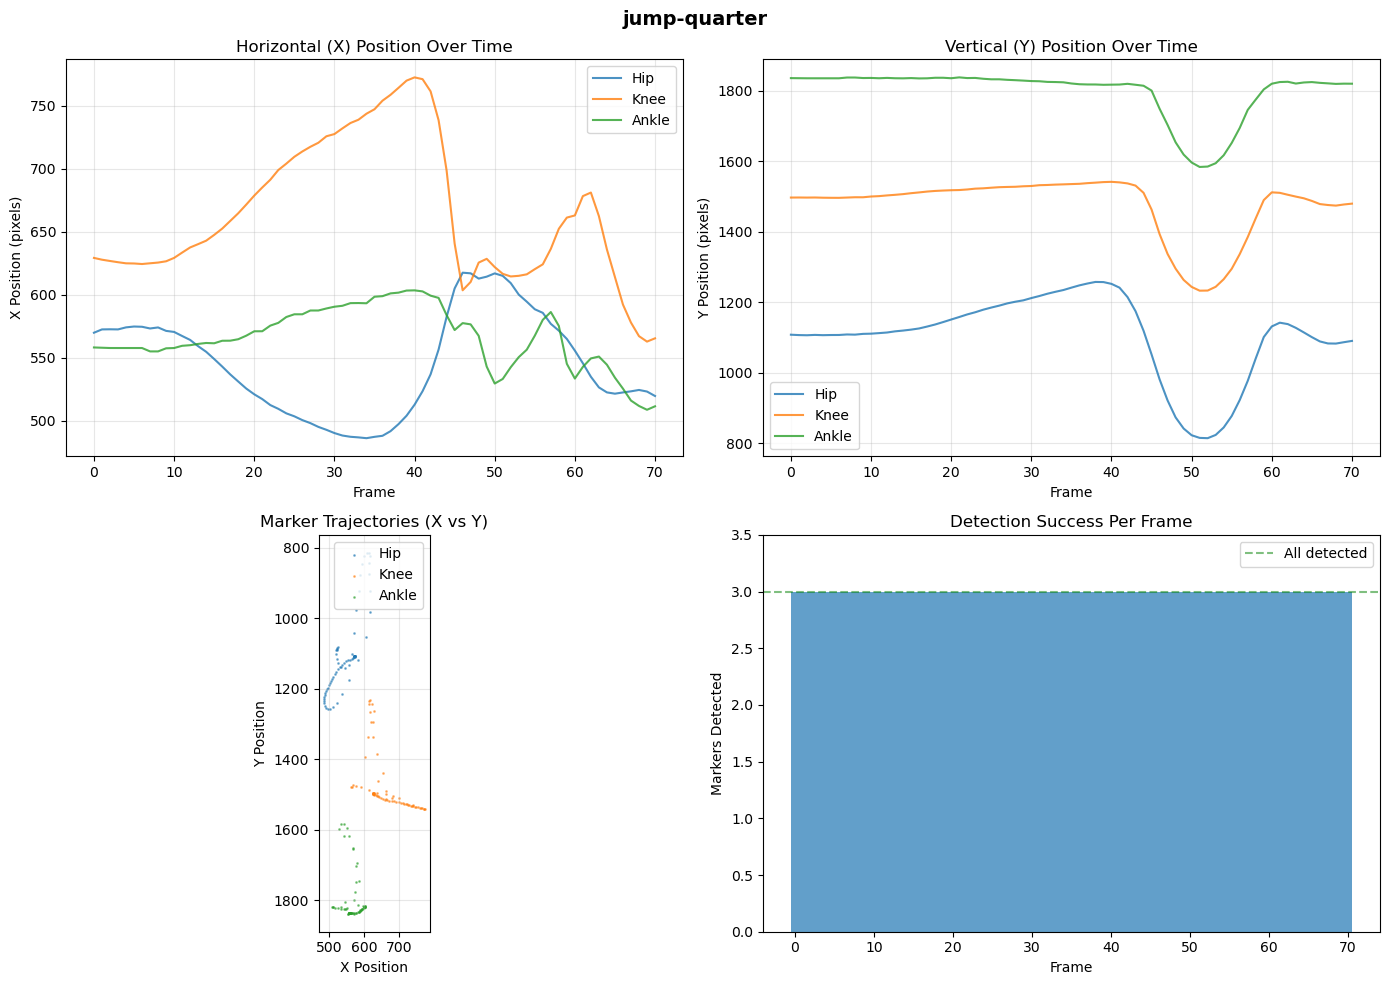

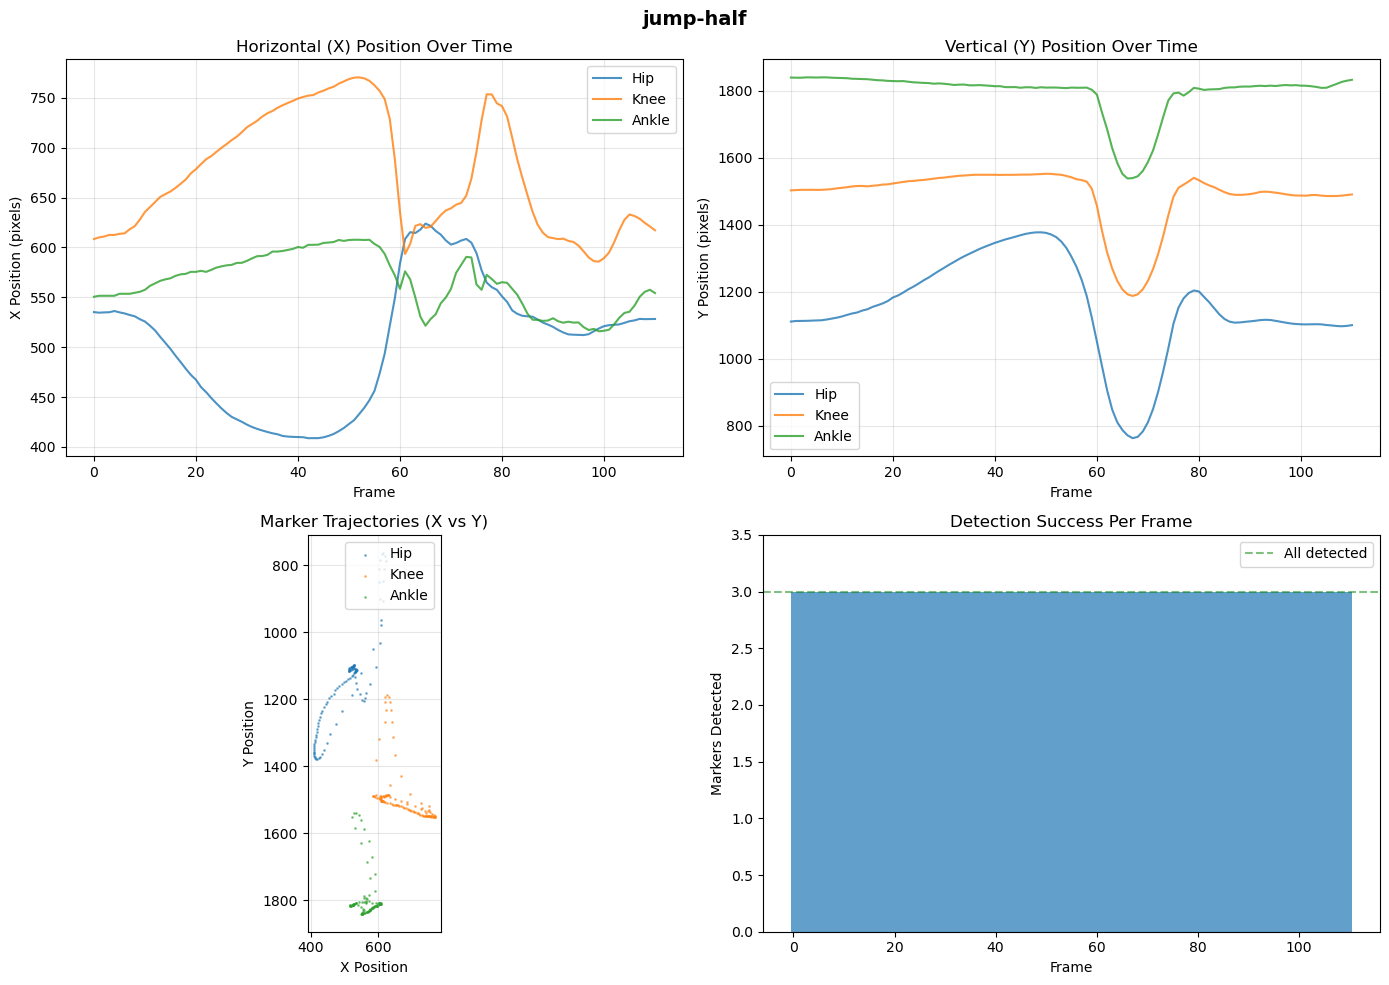

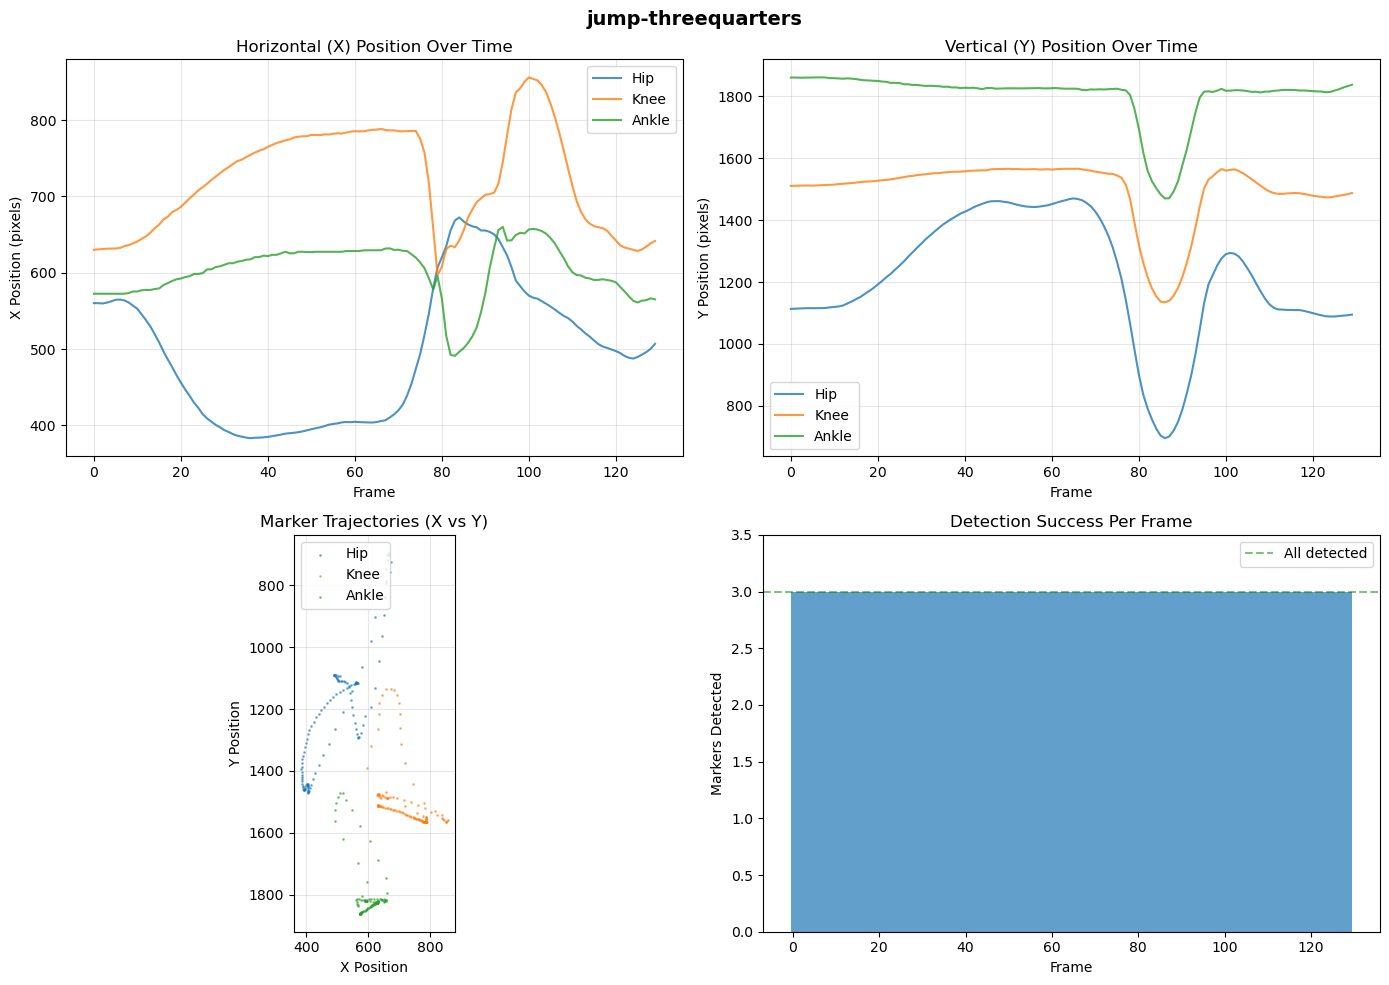

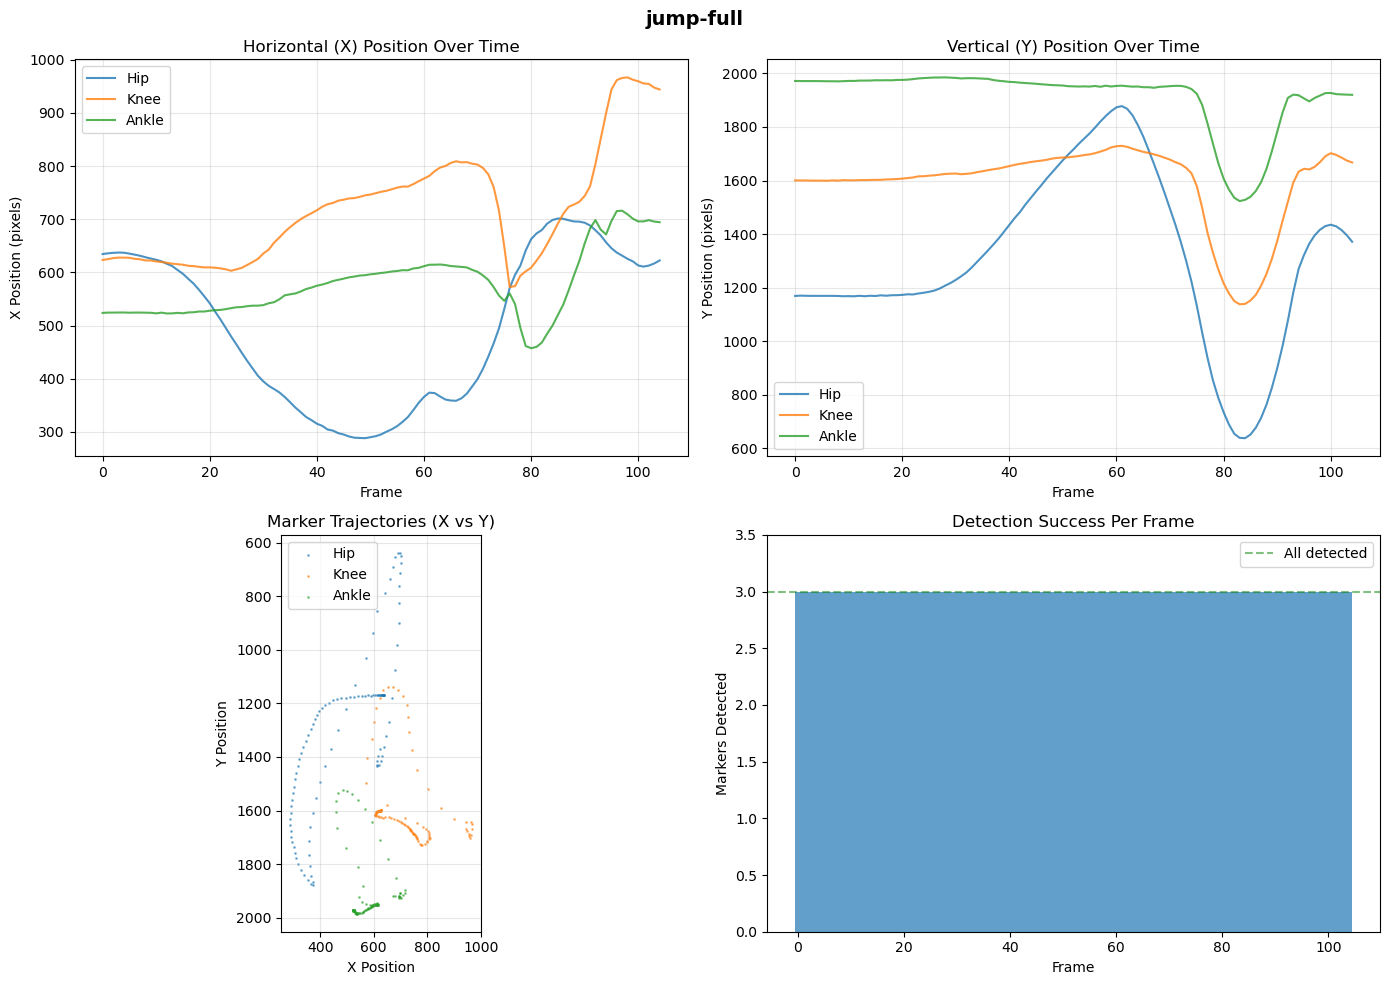

In [10]:
for video_name, df in all_dataframes.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{video_name}", fontsize=14, fontweight='bold')

    # X positions
    ax = axes[0, 0]
    ax.plot(df['frame'], df['hip_x'], label='Hip', alpha=0.8)
    ax.plot(df['frame'], df['knee_x'], label='Knee', alpha=0.8)
    ax.plot(df['frame'], df['ankle_x'], label='Ankle', alpha=0.8)
    ax.set_xlabel('Frame')
    ax.set_ylabel('X Position (pixels)')
    ax.set_title('Horizontal (X) Position Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Y positions
    ax = axes[0, 1]
    ax.plot(df['frame'], df['hip_y'], label='Hip', alpha=0.8)
    ax.plot(df['frame'], df['knee_y'], label='Knee', alpha=0.8)
    ax.plot(df['frame'], df['ankle_y'], label='Ankle', alpha=0.8)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Y Position (pixels)')
    ax.set_title('Vertical (Y) Position Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Trajectory
    ax = axes[1, 0]
    ax.scatter(df['hip_x'], df['hip_y'], s=1, alpha=0.5, label='Hip')
    ax.scatter(df['knee_x'], df['knee_y'], s=1, alpha=0.5, label='Knee')
    ax.scatter(df['ankle_x'], df['ankle_y'], s=1, alpha=0.5, label='Ankle')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title('Marker Trajectories (X vs Y)')
    ax.legend()
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Detection success
    ax = axes[1, 1]
    markers_per_frame = df[['hip_x', 'knee_x', 'ankle_x']].notna().sum(axis=1)
    ax.bar(df['frame'], markers_per_frame, width=1.0, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Markers Detected')
    ax.set_title('Detection Success Per Frame')
    ax.set_ylim(0, 3.5)
    ax.axhline(y=3, color='green', linestyle='--', alpha=0.5, label='All detected')
    ax.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{video_name}_analysis.png", dpi=150)
    plt.show()

## Per-Video Knee Angle Plots

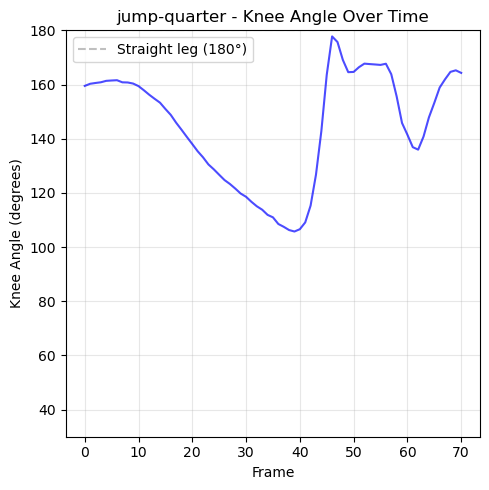

jump-quarter - Knee Angle: Min=105.7°, Max=177.8°, Mean=144.7°, Range=72.0°



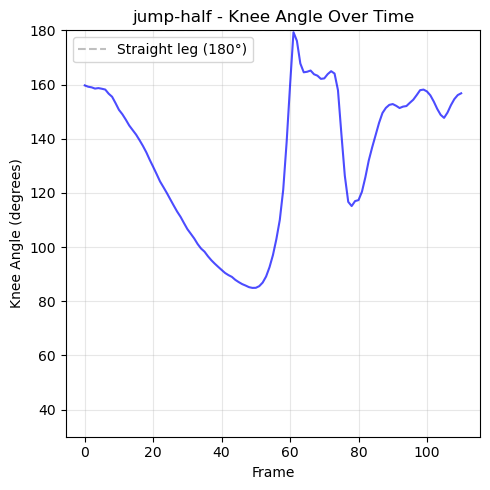

jump-half - Knee Angle: Min=84.9°, Max=179.3°, Mean=133.0°, Range=94.4°



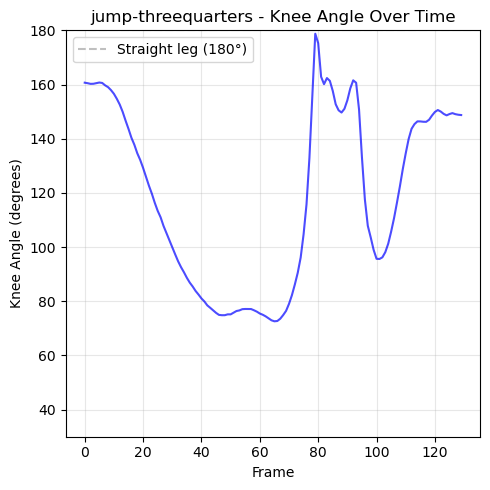

jump-threequarters - Knee Angle: Min=72.6°, Max=178.8°, Mean=118.8°, Range=106.1°



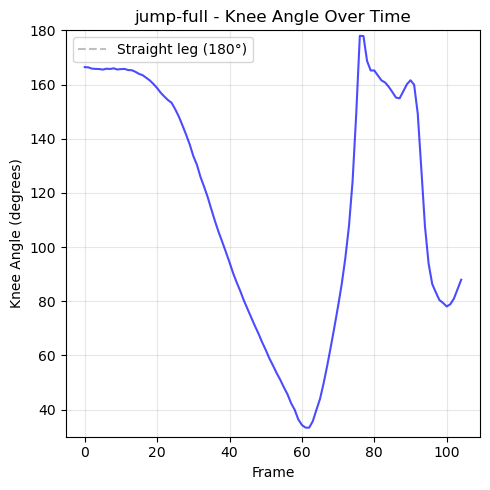

jump-full - Knee Angle: Min=33.3°, Max=178.0°, Mean=115.9°, Range=144.6°



In [27]:
for video_name, df in all_dataframes.items():
    plt.figure(figsize=(5, 5))
    plt.plot(df['frame'], df['knee_angle'], 'b-', alpha=0.7)
    plt.xlabel('Frame')
    plt.ylabel('Knee Angle (degrees)')
    plt.title(f'{video_name} - Knee Angle Over Time')
    plt.axhline(y=180, color='gray', linestyle='--', alpha=0.5, label='Straight leg (180\u00b0)')
    plt.ylim(30, 180)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{video_name}_knee_angle.png", dpi=150)
    plt.show()

    print(f"{video_name} - Knee Angle: "
          f"Min={df['knee_angle'].min():.1f}\u00b0, "
          f"Max={df['knee_angle'].max():.1f}\u00b0, "
          f"Mean={df['knee_angle'].mean():.1f}\u00b0, "
          f"Range={df['knee_angle'].max() - df['knee_angle'].min():.1f}\u00b0")
    print()

## Combined Comparison Across All Jumps

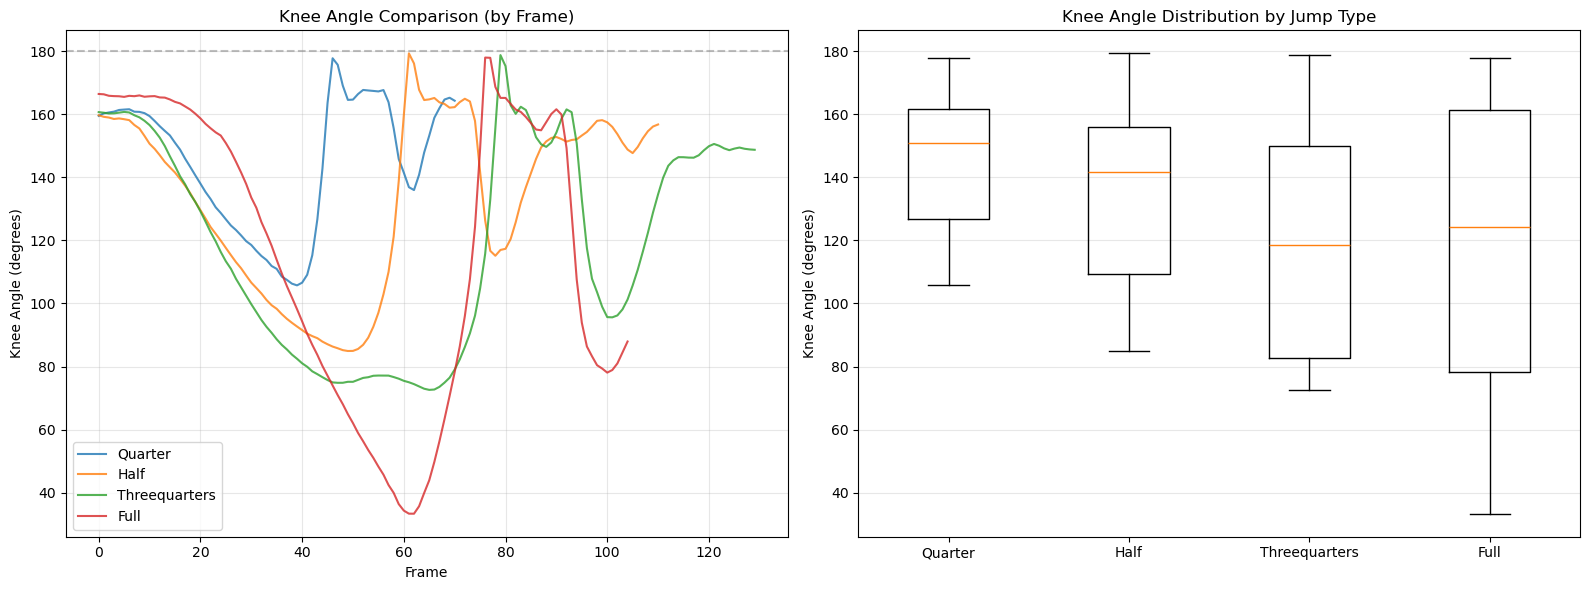

In [14]:
# Knee angle comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Knee angle over frames
ax = axes[0]
for video_name, df in all_dataframes.items():
    label = video_name.replace('jump-', '').title()
    ax.plot(df['frame'], df['knee_angle'], alpha=0.8, label=label)
ax.set_xlabel('Frame')
ax.set_ylabel('Knee Angle (degrees)')
ax.set_title('Knee Angle Comparison (by Frame)')
ax.axhline(y=180, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Knee angle summary box plot
ax = axes[1]
angle_data = []
labels = []
for video_name, df in all_dataframes.items():
    valid = df['knee_angle'].dropna()
    angle_data.append(valid.values)
    labels.append(video_name.replace('jump-', '').title())
ax.boxplot(angle_data, labels=labels)
ax.set_ylabel('Knee Angle (degrees)')
ax.set_title('Knee Angle Distribution by Jump Type')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_knee_angle.png", dpi=150)
plt.show()

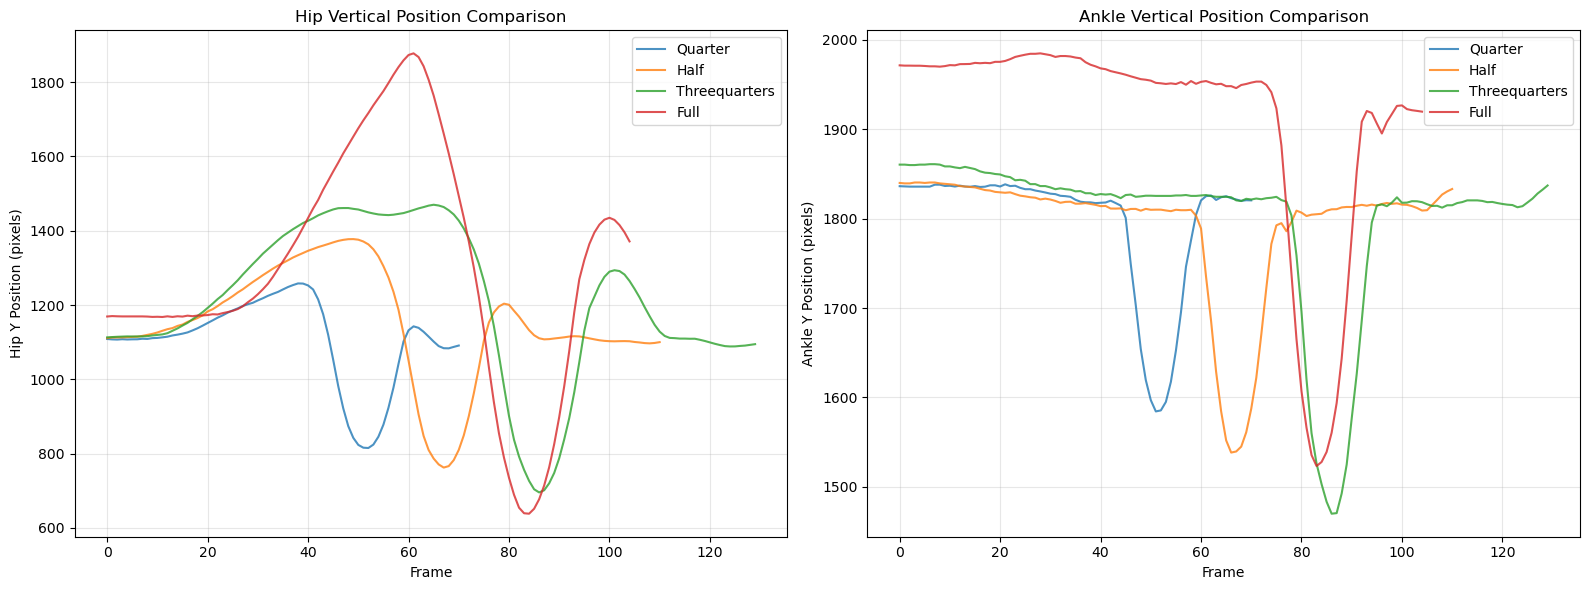

In [15]:
# Vertical displacement comparison (hip Y as proxy for jump height)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for video_name, df in all_dataframes.items():
    label = video_name.replace('jump-', '').title()
    ax.plot(df['frame'], df['hip_y'], alpha=0.8, label=label)
ax.set_xlabel('Frame')
ax.set_ylabel('Hip Y Position (pixels)')
ax.set_title('Hip Vertical Position Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for video_name, df in all_dataframes.items():
    label = video_name.replace('jump-', '').title()
    ax.plot(df['frame'], df['ankle_y'], alpha=0.8, label=label)
ax.set_xlabel('Frame')
ax.set_ylabel('Ankle Y Position (pixels)')
ax.set_title('Ankle Vertical Position Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_vertical_position.png", dpi=150)
plt.show()

## Summary Table

In [17]:
summary_rows = []
for video_name, df in all_dataframes.items():
    total = len(df)
    complete = df[['hip_x', 'knee_x', 'ankle_x']].notna().all(axis=1).sum()
    summary_rows.append({
        'Video': video_name,
        'Frames': total,
        'Detection Rate (%)': f"{100 * complete / total:.1f}",
        'Min Knee Angle': f"{df['knee_angle'].min():.1f}",
        'Max Knee Angle': f"{df['knee_angle'].max():.1f}",
        'Mean Knee Angle': f"{df['knee_angle'].mean():.1f}",
        'Knee Angle Range': f"{df['knee_angle'].max() - df['knee_angle'].min():.1f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / "summary.csv", index=False)
print("Summary saved to output/summary.csv")
summary_df

Summary saved to output/summary.csv


,Video,Frames,Detection Rate (%),Min Knee Angle,Max Knee Angle,Mean Knee Angle,Knee Angle Range
0,jump-quarter,71,100.0,105.7,177.8,144.7,72.0
1,jump-half,111,100.0,84.9,179.3,133.0,94.4
2,jump-threequarters,130,100.0,72.6,178.8,118.8,106.1
3,jump-full,105,100.0,33.3,178.0,115.9,144.6
